In [1]:
import numpy as np 
import torchaudio 

import torch 
import scipy 

from pathlib import Path

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [112]:
import warnings 
import librosa

def fxn():
    warnings.warn("user", UserWarning)


def get_excerpt(wav_path, rate, target_start, target_end, audio_dur, excerpt_dur=3, right_cutoff = 0.55, resamp_on_read=False):
    '''Creates audio excerpt from parent file with
    durration `dur` from metadata.
    Given duration and target event times, calculates
    excerpt start time code (in s) to begin reading from.
    Uses librosa.load to read only the desired portion
    of the parent file from start time (in s) to start 
    time plus durration `dur`.'''

    ## calc excerpt start time from targe time codes
    target_dur_in_s = target_end - target_start
    dur_edge_pad_in_s = (excerpt_dur - target_dur_in_s) / 2
    right_edge = target_end + dur_edge_pad_in_s
    # get lead in time
    excerpt_start = target_start - dur_edge_pad_in_s
    if excerpt_start < 0:
        excerpt_start = 0

    elif right_edge >= audio_dur:
        excerpt_start = audio_dur - excerpt_dur
    
    excerpt_end = excerpt_start + excerpt_dur
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fxn()
        if resamp_on_read:
            ### COPY THIS
            wav, _ = librosa.load(wav_path, sr = rate,
                                offset = excerpt_start,
                                duration = excerpt_dur,                    
                                res_type='soxr_hq',
                                dtype='float32')
        else:
            wav, _ = librosa.load(wav_path, sr = rate,
                                offset = excerpt_start,
                                duration = excerpt_dur,
                                dtype='float32')
        
    return wav, excerpt_start, excerpt_end

In [2]:
brir_path = Path('/om/user/francl/Room_Simulator_20181115_Rebuild/')

In [3]:
! ls {brir_path}

2_mic_test_HRIRs
Anechoic_HRIRdist140-5deg_elev_az_room5x5y5z_materials26wall26floor26ciel
Expanded_HRIRdist140-5deg_elev_az_room10x10y4z_materials11wall22floor20ciel
Expanded_HRIRdist140-5deg_elev_az_room3x3y4z_materials23wall23floor26ciel
Expanded_HRIRdist140-5deg_elev_az_room5x4y2z_materials1wall15floor16ciel
Expanded_HRIRdist140-5deg_elev_az_room6x4y3z_materials5wall13floor17ciel
Expanded_HRIRdist140-5deg_elev_az_room8x5y5z_materials8wall14floor16ciel
Expanded_HRIRdist140-5deg_elev_az_room9x9y10z_materials5wall14floor17ciel
HRIRdist140-5deg_elev_az_room10x10y4z_materials11wall22floor20ciel
HRIRdist140-5deg_elev_az_room3x3y4z_materials23wall23floor26ciel
HRIRdist140-5deg_elev_az_room5x4y2z_materials1wall15floor16ciel
HRIRdist140-5deg_elev_az_room8x5y5z_materials8wall14floor16ciel
HRIRdist140-5deg_elev_az_room9x9y10z_materials5wall14floor17ciel
HRTFs
acoeff_hrtf.m
calc_num_pos.py
choose_loc.py
core.29555
core.38039
core.51786
core.82104
core.82198
data_locs.mat
env_vary_inner_loop.sh

In [4]:
# eg_room = brir_path / 'Expanded_HRIRdist140-5deg_elev_az_room9x9y10z_materials5wall14floor17ciel'
eg_room = brir_path / 'Expanded_HRIRdist140-5deg_elev_az_room3x3y4z_materials23wall23floor26ciel'


In [5]:
irs = list(eg_room.glob('*r.wav'))

In [6]:
irs[0]

PosixPath('/om/user/francl/Room_Simulator_20181115_Rebuild/Expanded_HRIRdist140-5deg_elev_az_room3x3y4z_materials23wall23floor26ciel/-20elev_75az_1.40x1.40y2.00z_r.wav')

In [7]:
'_'.join(irs[0].stem.split('_')[:-1])

'-20elev_75az_1.40x1.40y2.00z'

In [8]:
wav,sr = torchaudio.load(irs[0])

In [9]:
wav.shape[1] / sr


0.5

In [10]:
locations, counts = np.unique([ir.stem.split('_')[2:][0] for ir in irs], return_counts=True) 


In [11]:
counts


array([1944, 1944, 1944, 1944])

In [12]:
## Make location dict:
# Remove l & r tag from
loc_dict = {loc: ['_'.join(ir.stem.split('_')[:-1]) for ir in irs if loc in ir.stem] for loc in locations}

In [13]:
{loc:len(irs) for loc, irs in loc_dict.items()}

{'1.40x1.40y2.00z': 1944,
 '1.40x1.60y2.00z': 1944,
 '1.60x1.40y2.00z': 1944,
 '1.60x1.60y2.00z': 1944}

In [14]:
(np.vstack([locations,counts]).T[:,1] == '1944').all()

True

In [56]:
## Room irs eg
import librosa

room = '1.40x1.40y2.00z'

room_irs = loc_dict[room]

n_sources = len(room_irs)

ir_paths = [(path + '_l.wav', path + '_r.wav') for path in room_irs]
# print(ir_paths)

# Get tensor of irs as "kernel"

goal_r = 50_000
ir_dur = 0.5 # dur in seconds 
### USE NUMPY, LOCATIONS INSTEAD OF SOURCES
ir_kernel = np.zeros((n_sources, 2, int(goal_r * ir_dur)))
azimuth_kernel = np.zeros((n_sources, 1))
elevation_kernel = np.zeros((n_sources, 1))

for ix,  (left_ir, right_ir) in enumerate(ir_paths):
    ### USE LIBROSA COMMAND HERE
    left_ir_up, sr = librosa.load(eg_room/left_ir, sr = goal_r,                    
                                res_type='soxr_vhq',
                                dtype='float32')
    right_ir_up, sr = librosa.load(eg_room/right_ir, sr = goal_r,                    
                                res_type='soxr_vhq',
                                dtype='float32')

    ### ADD THESE TO N x 2 x T array
    ir_kernel[ix][0] = left_ir_up
    ir_kernel[ix][1] = right_ir_up
    
    ### ADD TO two N x 1 Azimuth and Elevation arrays as int
    elev, az = left_ir.split('_')[:2]
    azimuth_kernel[ix] = int(az[:-2])
    elevation_kernel[ix] = int(elev[:-4])


# convolve sigs with brirs

In [50]:
room = '1.40x1.40y2.00z'

room_irs = loc_dict[room]

n_sources = 10

ir_paths = [(path + '_l.wav', path + '_r.wav') for path in np.random.choice(room_irs, size=n_sources, replace=False)]

irs = ir_paths[0]
el, az = irs[0].split('_')[:2]
print(el, az)
int(az[:-2])

-35elev 255az


255

In [224]:
left_ir.shape

torch.Size([1, 22050])

In [225]:
from IPython.display import Audio
Audio(left_ir, rate=sr)

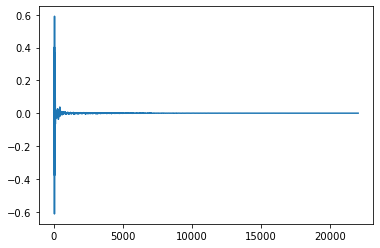

In [226]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(left_ir.T);

In [227]:
spatial_examps = torch.nn.functional.conv1d(examps[:n_sources,...].view(n_sources,1,-1),
                                            ir_kernel.view(n_sources*2,1,-1))

In [228]:
print(spatial_examps.shape)

samp_ixs = torch.arange(n_sources).repeat_interleave(2)
wanted_ir_ixs = torch.arange(start=0, end=n_sources*2)

spatial_examps_binaural= spatial_examps[samp_ixs, wanted_ir_ixs, : ].view(n_sources,2,-1)
# spatial_examps_binaural = torch.stack([spatial_examps_l, spatial_examps_r], dim=1)

print(spatial_examps_binaural.shape)

torch.Size([10, 20, 110251])
torch.Size([10, 2, 110251])


22049

In [229]:
from IPython.display import Audio

examp_ix = 5
print(ir_paths[examp_ix])
Audio(spatial_examps_binaural[examp_ix,:,:], rate=sr)

('-25elev_125az_1.40x1.40y2.00z_l.wav', '-25elev_125az_1.40x1.40y2.00z_r.wav')


In [230]:
Audio(examps[examp_ix,...].squeeze(0), rate=sr)

## Write in numpy 

In [213]:
import numpy as np 
import soundfile as sf # use sound file to load wavs
from scipy import signal


In [244]:
## Room irs eg

room = '1.40x1.40y2.00z'

room_irs = loc_dict[room]

examps_np = examps.numpy()
print(examps_np.shape)

n_sources = 10

# ir_paths = [(path + '_l.wav', path + '_r.wav') for path in np.random.choice(room_irs, size=n_sources, replace=False)]
# use same ir paths as above for sanity checkign 
print(ir_paths)

# Get tensor of irs as "kernel"

sr = 44100
ir_dur = 0.5 # dur in seconds 
ir_kernel = np.zeros((n_sources, 2, int(sr * ir_dur)))

for ix,  (left_ir, right_ir) in enumerate(ir_paths):
    left_ir, sr = sf.read(eg_room/left_ir)
    right_ir, sr = sf.read(eg_room/right_ir)
    ir_kernel[ix, 0, : ] = left_ir 
    ir_kernel[ix, 1, :] =right_ir

print(ir_kernel.shape)
print(examps_np.shape)

# convolve sigs with brirs
spatial_examps_np = signal.convolve(examps_np.reshape(n_sources,1,-1), ir_kernel.reshape(1,n_sources*2,-1), mode='full')
print(spatial_examps.shape)
# Get single location for each channel:

samp_ixs = np.repeat(np.arange(n_sources), 2) 
wanted_ir_ixs = np.arange(start=0, stop=n_sources*2)

spatial_examps_binaural_np = spatial_examps_np[samp_ixs, wanted_ir_ixs, : ].reshape(n_sources,2,-1)
print(spatial_examps_binaural_np.shape)

# cut to desired length
pad_added = np.ceil((int(sr * ir_dur) - 1)).astype('int')
spatial_examps_binaural_np = spatial_examps_binaural_np[..., pad_added : - pad_added]
print(spatial_examps_binaural_np.shape)


(10, 132300)
[('-15elev_20az_1.40x1.40y2.00z_l.wav', '-15elev_20az_1.40x1.40y2.00z_r.wav'), ('90elev_285az_1.40x1.40y2.00z_l.wav', '90elev_285az_1.40x1.40y2.00z_r.wav'), ('35elev_345az_1.40x1.40y2.00z_l.wav', '35elev_345az_1.40x1.40y2.00z_r.wav'), ('-10elev_235az_1.40x1.40y2.00z_l.wav', '-10elev_235az_1.40x1.40y2.00z_r.wav'), ('-10elev_195az_1.40x1.40y2.00z_l.wav', '-10elev_195az_1.40x1.40y2.00z_r.wav'), ('-25elev_125az_1.40x1.40y2.00z_l.wav', '-25elev_125az_1.40x1.40y2.00z_r.wav'), ('-20elev_175az_1.40x1.40y2.00z_l.wav', '-20elev_175az_1.40x1.40y2.00z_r.wav'), ('-5elev_50az_1.40x1.40y2.00z_l.wav', '-5elev_50az_1.40x1.40y2.00z_r.wav'), ('0elev_270az_1.40x1.40y2.00z_l.wav', '0elev_270az_1.40x1.40y2.00z_r.wav'), ('5elev_90az_1.40x1.40y2.00z_l.wav', '5elev_90az_1.40x1.40y2.00z_r.wav')]
(10, 2, 22050)
(10, 132300)
torch.Size([10, 20, 110251])
(10, 2, 154349)
(10, 2, 110251)


In [282]:
from IPython.display import Audio

examp_ix = 8
print(ir_paths[examp_ix])
Audio(spatial_examps_binaural_np[examp_ix,:,:], rate=sr)

('0elev_270az_1.40x1.40y2.00z_l.wav', '0elev_270az_1.40x1.40y2.00z_r.wav')


In [246]:
Audio(examps_np[examp_ix], rate=sr)

In [249]:
### compare to torch

np_eg = spatial_examps_binaural_np[examp_ix,:,:] 
torch_eg = spatial_examps_binaural[examp_ix,:,:].numpy()

In [250]:
torch_eg.shape, np_eg.shape


((2, 110251), (2, 110251))

In [277]:
np.abs(torch_eg - np_eg).mean()

2.4787637421270786e-07

In [267]:
 val_b2 = 2**(-24) 

In [268]:
np.log2(val_b2)

-24.0

In [276]:
np.log2(val_b2)/np.log2(10)

-7.224719895935549